<a href="https://colab.research.google.com/github/Esther-Assena-pro/CINEMA-PROJECT/blob/master/analyse_clients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

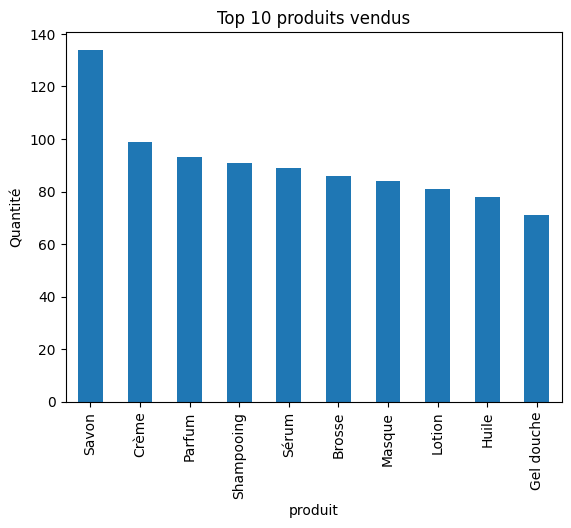

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/smartCustomer_Project/data/clients_achats.csv')

df['date_achat'] = pd.to_datetime(df['date_achat'])

df['mois'] = df['date_achat'].dt.month
df['jour_semaine'] = df['date_achat'].dt.day_name()
df['heure'] = df['date_achat'].dt.hour

top_produits = df.groupby('produit')['quantité'].sum().sort_values(ascending=False).head(10)
top_produits.plot(kind= 'bar', title='Top 10 produits vendus')
plt.ylabel('Quantité')
plt.show()

Aperçu des données :
  client_id     produit  quantité  prix_unitaire           date_achat  \
0     C0021      Parfum         4          38.74  2023-05-27 09:02:00   
1     C0014      Brosse         3          43.20  2023-08-27 10:02:00   
2     C0019      Parfum         2          45.11  2023-07-02 22:47:00   
3     C0050       Huile         4          35.41  2023-07-28 03:31:00   
4     C0007  Shampooing         4          30.68  2024-12-08 10:43:00   

  moyen_paiement  montant  
0         Chèque   154.96  
1        Espèces   129.60  
2        Espèces    90.22  
3         Chèque   141.64  
4        Espèces   122.72  

Dimensions
(300, 7)
\info sur les colones :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   client_id       300 non-null    object 
 1   produit         300 non-null    object 
 2   quantité        300 non-null    int64 

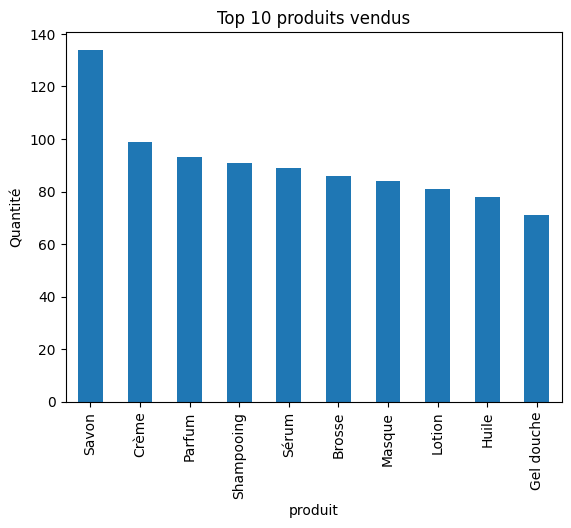

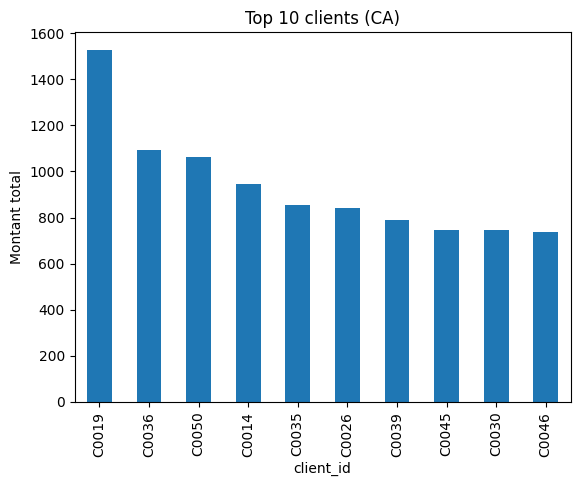

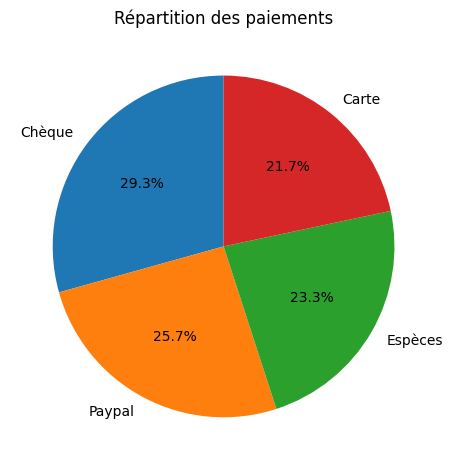

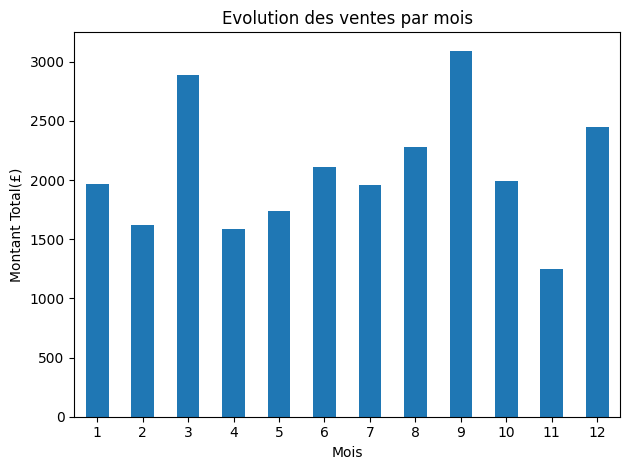

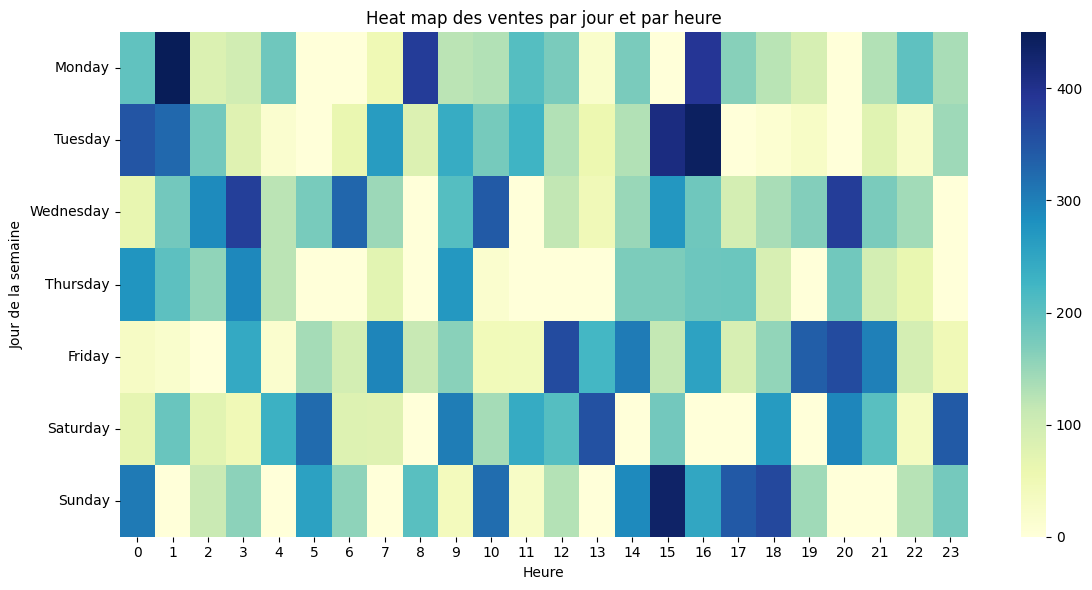

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/smartCustomer_Project/data/clients_achats.csv')
print("Aperçu des données :")
print(df.head())
print("\nDimensions")
print(df.shape)
print("\info sur les colones :")
df.info()
print("\nStatistiques descriptives :")
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
df['montant_calcule'] = df['quantité'] * df['prix_unitaire']
print((df['montant'] != df['montant_calcule'].sum()))
df['date_achat'] = pd.to_datetime(df['date_achat'])
df.sort_values(by='montant', ascending=False).head()

df['mois'] = df['date_achat'].dt.month
df['jour_semaine'] = df['date_achat'].dt.day_name()
df['heure'] = df['date_achat'].dt.hour

top_produits = df.groupby('produit')['quantité'].sum().sort_values(ascending=False).head(10)
top_produits.plot(kind= 'bar', title='Top 10 produits vendus')
plt.ylabel('Quantité')
plt.show()

top_clients = df.groupby('client_id')['montant'].sum().sort_values(ascending=False).head(10)
top_clients.plot(kind='bar', title='Top 10 clients (CA)')
plt.ylabel('Montant total')
plt.show()

paiements = df['moyen_paiement'].value_counts()


paiements.plot(kind='pie', autopct='%1.1f%%', startangle= 90, title='Répartition des paiements')
plt.ylabel('')
plt.tight_layout()
plt.show()

ventes_par_mois = df.groupby('mois')['montant'].sum()

ventes_par_mois.plot(kind='bar', title='Evolution des ventes par mois')
plt.xlabel('Mois')
plt.ylabel('Montant Total(£)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Regrouper par jour/heure
heatmap_data = df.groupby(['jour_semaine', 'heure'])['montant'].sum().unstack().fillna(0)

#Reordonner les jours dans l'ordre logique
jours = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data= heatmap_data.reindex(jours)

#Visualisation
plt.figure(figsize= (12,6))
sns.heatmap(heatmap_data, cmap= 'YlGnBu')
plt.title('Heat map des ventes par jour et par heure')
plt.xlabel('Heure')
plt.ylabel('Jour de la semaine')
plt.tight_layout()
plt.show()





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
